In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

from sklearn.calibration import calibration_curve

from sklearn.utils import resample
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from config.paths import config

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Define the WeightedAverageEnsemble class first to avoid loading errors
class WeightedAverageEnsemble:
    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def fit(self, X, y):
        for model in self.models:
            model.fit(X, y)
        return self

    def predict_proba(self, X):
        probas = [model.predict_proba(X) for model in self.models]
        return np.average(probas, axis=0, weights=self.weights)

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)

# Now load the data and models
processed_data = joblib.load(config.processed_data_dir / "feature_engineered_data.pkl")
tuning_results = joblib.load(config.models_dir / "tuned_models.pkl")

X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Best model from tuning: {tuning_results['best_model']['name']}")

Training data: (156156, 92)
Testing data: (39040, 92)
Best model from tuning: LightGBM


In [3]:
def evaluate_model_comprehensively(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    metrics = {}

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    metrics['accuracy'] = accuracy_score(y_test, y_pred)
    metrics['precision'] = precision_score(y_test, y_pred)
    metrics['recall'] = recall_score(y_test, y_pred)
    metrics['f1'] = f1_score(y_test, y_pred)
    metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_proba, n_bins=10)

    return {
        'metrics': metrics,
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall,
        'calibration_curve': (fraction_of_positives, mean_predicted_value),
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred
    }

In [4]:
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

all_models_results = {}

best_model_name = tuning_results['best_model']['name']
best_model = tuning_results['best_model']['model']

print(f"Evaluating best model: {best_model_name}")

all_models_results[best_model_name] = evaluate_model_comprehensively(
    best_model, X_test, y_test, best_model_name
)

for model_name, model in tuning_results['all_models'].items():
    if model_name != best_model_name:
        print(f"Evaluating {model_name}")
        all_models_results[model_name] = evaluate_model_comprehensively(
            model, X_test, y_test, model_name
        )

COMPREHENSIVE MODEL EVALUATION
Evaluating best model: LightGBM
Evaluating XGBoost
Evaluating Random Forest
Evaluating Logistic Regression
Evaluating Weighted_Ensemble


In [5]:
performance_matrix = []

for model_name, results in all_models_results.items():
    metrics = results['metrics']
    performance_matrix.append({
        'Model': model_name,
        'Accuracy': f"{metrics['accuracy']:.6f}",
        'Precision': f"{metrics['precision']:.6f}",
        'Recall': f"{metrics['recall']:.6f}",
        'F1-Score': f"{metrics['f1']:.6f}",
        'ROC-AUC': f"{metrics['roc_auc']:.6f}"
    })

performance_df = pd.DataFrame(performance_matrix)
print("\nPERFORMANCE MATRIX COMPARISON:")
print("=" * 80)
print(performance_df.to_string(index=False))


PERFORMANCE MATRIX COMPARISON:
              Model Accuracy Precision   Recall F1-Score  ROC-AUC
           LightGBM 0.986757  0.979681 0.975343 0.977507 0.998884
            XGBoost 0.986322  0.979651 0.973867 0.976750 0.998863
      Random Forest 0.978560  0.969577 0.957371 0.963435 0.997059
Logistic Regression 0.977741  0.965713 0.958587 0.962137 0.996245
  Weighted_Ensemble 0.985143  0.978897 0.970568 0.974714 0.998539


In [6]:
print("FINAL MODEL SELECTION AND CALIBRATION")
print("=" * 60)

final_model = tuning_results['best_model']['model']
final_model_name = tuning_results['best_model']['name']

print(f"Selected final model: {final_model_name}")

calibrated_model = CalibratedClassifierCV(final_model, method='sigmoid', cv=3)
calibrated_model.fit(X_train, y_train)

print("Model calibration completed")

calibrated_results = evaluate_model_comprehensively(
    calibrated_model, X_test, y_test, f"{final_model_name} (Calibrated)"
)

print("\nCALIBRATION COMPARISON:")
print(f"Original ROC-AUC: {all_models_results[final_model_name]['metrics']['roc_auc']:.6f}")
print(f"Calibrated ROC-AUC: {calibrated_results['metrics']['roc_auc']:.6f}")

FINAL MODEL SELECTION AND CALIBRATION
Selected final model: LightGBM
Model calibration completed

CALIBRATION COMPARISON:
Original ROC-AUC: 0.998884
Calibrated ROC-AUC: 0.998889


In [7]:
def bootstrap_confidence_intervals(model, X, y, n_bootstrap=100):
    metrics_list = []

    for i in range(n_bootstrap):
        X_bs, y_bs = resample(X, y, random_state=i)
        y_pred_proba = model.predict_proba(X_bs)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)

        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
        metrics_list.append({
            'accuracy': accuracy_score(y_bs, y_pred),
            'precision': precision_score(y_bs, y_pred),
            'recall': recall_score(y_bs, y_pred),
            'f1': f1_score(y_bs, y_pred),
            'roc_auc': roc_auc_score(y_bs, y_pred_proba)
        })

    metrics_df = pd.DataFrame(metrics_list)
    confidence_intervals = {}

    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        mean_val = metrics_df[metric].mean()
        std_val = metrics_df[metric].std()
        ci_lower = mean_val - 1.96 * std_val
        ci_upper = mean_val + 1.96 * std_val
        confidence_intervals[metric] = {
            'mean': mean_val,
            'std': std_val,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        }

    return confidence_intervals

print("CALCULATING CONFIDENCE INTERVALS...")
confidence_intervals = bootstrap_confidence_intervals(calibrated_model, X_test, y_test)

print("\nBOOTSTRAP CONFIDENCE INTERVALS (95%):")
for metric, ci in confidence_intervals.items():
    print(f"{metric.upper():12}: {ci['mean']:.4f} ± {ci['std']:.4f} "
          f"({ci['ci_lower']:.4f} - {ci['ci_upper']:.4f})")

CALCULATING CONFIDENCE INTERVALS...

BOOTSTRAP CONFIDENCE INTERVALS (95%):
ACCURACY    : 0.9870 ± 0.0006 (0.9858 - 0.9883)
PRECISION   : 0.9813 ± 0.0013 (0.9788 - 0.9839)
RECALL      : 0.9745 ± 0.0016 (0.9713 - 0.9777)
F1          : 0.9779 ± 0.0011 (0.9758 - 0.9800)
ROC_AUC     : 0.9989 ± 0.0001 (0.9988 - 0.9990)


COMPREHENSIVE TEST EVALUATION VISUALIZATIONS


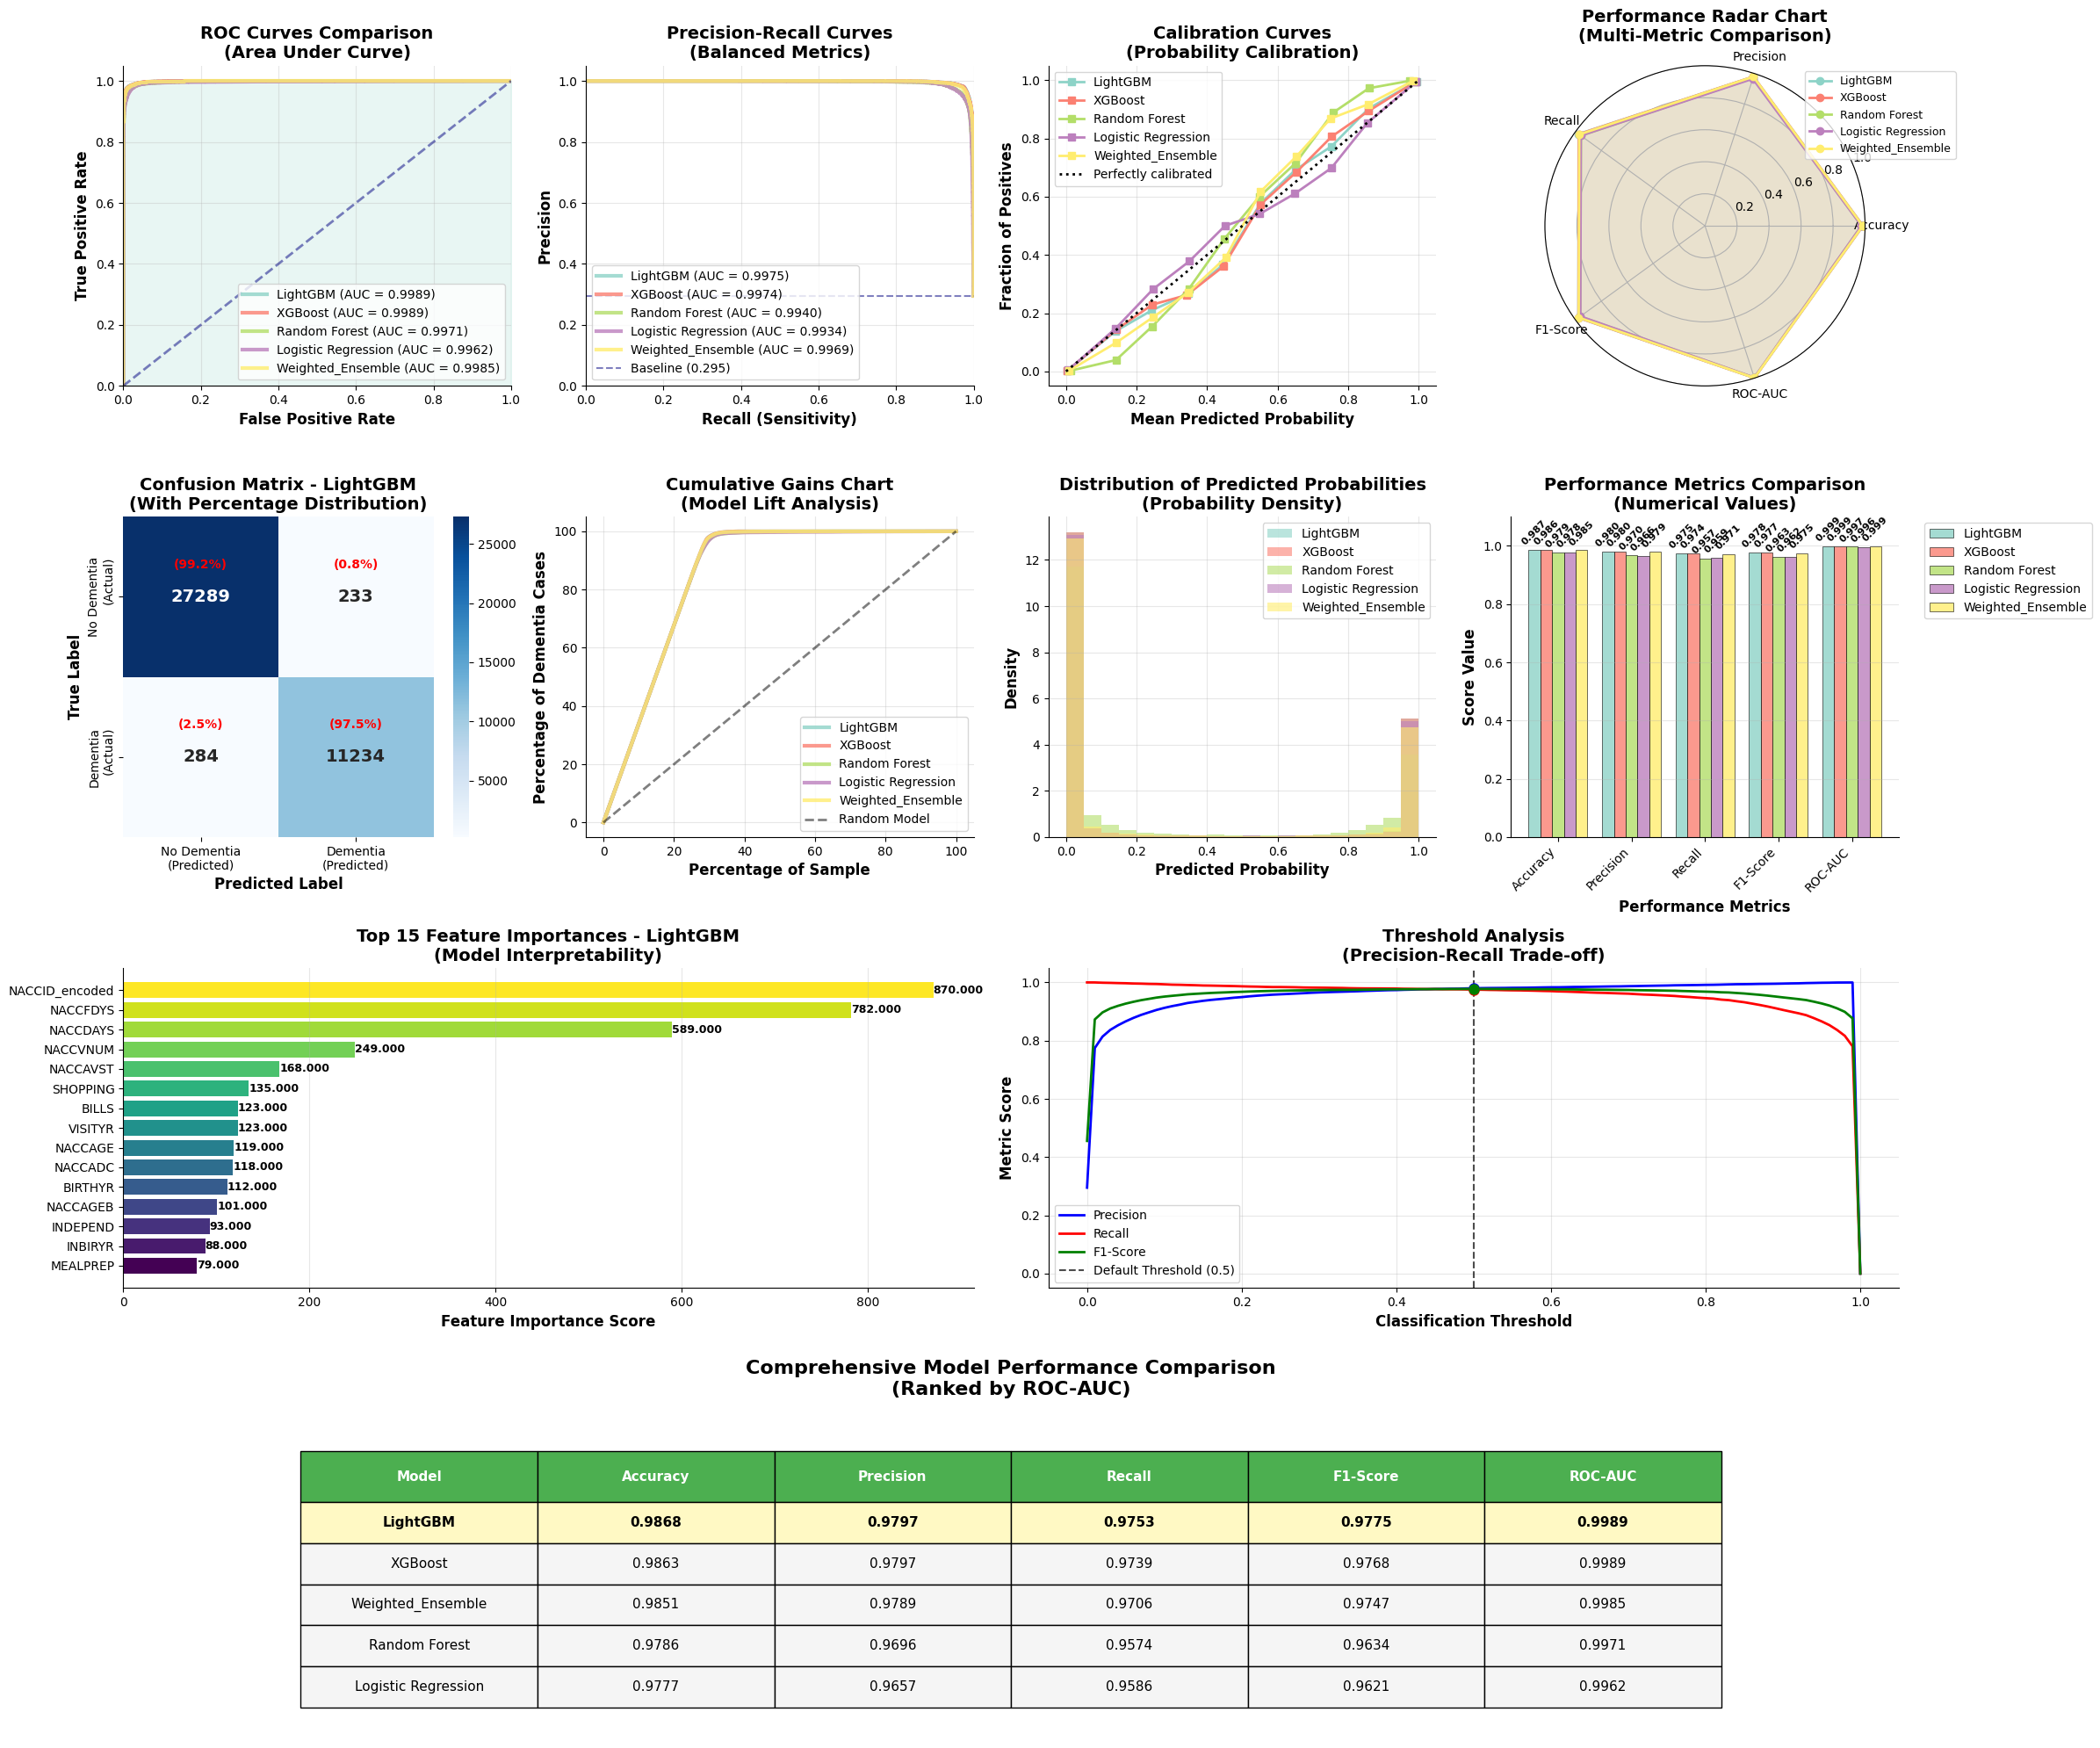

In [8]:
from sklearn.metrics import auc

print("COMPREHENSIVE TEST EVALUATION VISUALIZATIONS")
print("=" * 60)

# Create a comprehensive dashboard with enhanced visualizations
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(4, 4)

# Define colors for different models
colors = plt.cm.Set3(np.linspace(0, 1, len(all_models_results)))

# 1. Enhanced ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
for i, (model_name, results) in enumerate(all_models_results.items()):
    fpr, tpr = results['fpr'], results['tpr']
    roc_auc = results['metrics']['roc_auc']
    ax1.plot(fpr, tpr, color=colors[i], lw=3,
            label=f'{model_name} (AUC = {roc_auc:.4f})', alpha=0.8)

    # Add fill between for the best model
    if model_name == final_model_name:
        ax1.fill_between(fpr, tpr, alpha=0.2, color=colors[i])

ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax1.set_title('ROC Curves Comparison\n(Area Under Curve)', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. Enhanced Precision-Recall Curves
ax2 = fig.add_subplot(gs[0, 1])
for i, (model_name, results) in enumerate(all_models_results.items()):
    precision, recall = results['precision'], results['recall']
    auc_pr = auc(recall, precision)
    ax2.plot(recall, precision, color=colors[i], lw=3,
            label=f'{model_name} (AUC = {auc_pr:.4f})', alpha=0.8)

baseline = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=baseline, color='navy', linestyle='--', alpha=0.5,
           label=f'Baseline ({baseline:.3f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax2.set_title('Precision-Recall Curves\n(Balanced Metrics)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 3. Enhanced Calibration Curves
ax3 = fig.add_subplot(gs[0, 2])
for i, (model_name, results) in enumerate(all_models_results.items()):
    fraction_of_positives, mean_predicted_value = results['calibration_curve']
    ax3.plot(mean_predicted_value, fraction_of_positives, "s-",
            color=colors[i], label=f'{model_name}', markersize=6, lw=2)

ax3.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated", lw=2)
ax3.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
ax3.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
ax3.set_title('Calibration Curves\n(Probability Calibration)', fontsize=14, fontweight='bold')
ax3.legend(loc="upper left", fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 4. Enhanced Metric Comparison Radar Chart
ax4 = fig.add_subplot(gs[0, 3], polar=True)
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
num_metrics = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for i, (model_name, results) in enumerate(all_models_results.items()):
    values = [
        results['metrics']['accuracy'],
        results['metrics']['precision'],
        results['metrics']['recall'],
        results['metrics']['f1'],
        results['metrics']['roc_auc']
    ]
    values += values[:1]  # Complete the circle
    ax4.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[i])
    ax4.fill(angles, values, alpha=0.1, color=colors[i])

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(metrics_radar, fontsize=10)
ax4.set_ylim(0, 1)
ax4.set_title('Performance Radar Chart\n(Multi-Metric Comparison)', fontsize=14, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
ax4.grid(True)

# 5. Enhanced Confusion Matrix for Best Model
ax5 = fig.add_subplot(gs[1, 0])
best_results = all_models_results[final_model_name]
cm = confusion_matrix(y_test, best_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['No Dementia\n(Predicted)', 'Dementia\n(Predicted)'],
            yticklabels=['No Dementia\n(Actual)', 'Dementia\n(Actual)'],
            annot_kws={"size": 14, "weight": "bold"})

# Calculate percentages for additional context
cm_percentage = cm / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax5.text(j+0.5, i+0.3, f'({cm_percentage[i,j]*100:.1f}%)',
                ha='center', va='center', fontsize=10, color='red', fontweight='bold')

ax5.set_title(f'Confusion Matrix - {final_model_name}\n(With Percentage Distribution)',
             fontsize=14, fontweight='bold')
ax5.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax5.set_ylabel('True Label', fontsize=12, fontweight='bold')

# 6. Enhanced Cumulative Gains Chart
ax6 = fig.add_subplot(gs[1, 1])
for i, (model_name, results) in enumerate(all_models_results.items()):
    y_pred_proba = results['y_pred_proba']
    data = pd.DataFrame({'prob': y_pred_proba, 'actual': y_test})
    data = data.sort_values('prob', ascending=False).reset_index(drop=True)
    data['cumulative_actual'] = data['actual'].cumsum()
    data['percentage'] = (data.index + 1) / len(data) * 100
    data['gain'] = data['cumulative_actual'] / data['actual'].sum() * 100

    ax6.plot(data['percentage'], data['gain'], color=colors[i],
            label=model_name, lw=3, alpha=0.8)

ax6.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Random Model', lw=2)
ax6.set_xlabel('Percentage of Sample', fontsize=12, fontweight='bold')
ax6.set_ylabel('Percentage of Dementia Cases', fontsize=12, fontweight='bold')
ax6.set_title('Cumulative Gains Chart\n(Model Lift Analysis)', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# 7. Enhanced Distribution of Predicted Probabilities
ax7 = fig.add_subplot(gs[1, 2])
bins = np.linspace(0, 1, 21)
for i, (model_name, results) in enumerate(all_models_results.items()):
    y_pred_proba = results['y_pred_proba']
    ax7.hist(y_pred_proba, bins=bins, alpha=0.6, color=colors[i],
            label=model_name, density=True)

ax7.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
ax7.set_ylabel('Density', fontsize=12, fontweight='bold')
ax7.set_title('Distribution of Predicted Probabilities\n(Probability Density)',
             fontsize=14, fontweight='bold')
ax7.legend(fontsize=10)
ax7.grid(True, alpha=0.3)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# 8. Enhanced Performance Metrics Bar Chart with Confidence Intervals
ax8 = fig.add_subplot(gs[1, 3])
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x_pos = np.arange(len(metrics_to_plot))
width = 0.8 / len(all_models_results)

for i, (model_name, results) in enumerate(all_models_results.items()):
    metric_values = [results['metrics'][metric] for metric in metrics_to_plot]
    bars = ax8.bar(x_pos + i * width, metric_values, width, label=model_name,
                  color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)

    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=8,
                fontweight='bold', rotation=45)

ax8.set_xlabel('Performance Metrics', fontsize=12, fontweight='bold')
ax8.set_ylabel('Score Value', fontsize=12, fontweight='bold')
ax8.set_title('Performance Metrics Comparison\n(Numerical Values)',
             fontsize=14, fontweight='bold')
ax8.set_xticks(x_pos + width * (len(all_models_results) - 1) / 2)
ax8.set_xticklabels(metric_names, rotation=45, ha='right')
ax8.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
ax8.set_ylim(0, 1.1)
ax8.grid(True, alpha=0.3, axis='y')
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)

# 9. Enhanced Feature Importance (if available)
if hasattr(final_model, 'feature_importances_'):
    ax9 = fig.add_subplot(gs[2, 0:2])
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(15)

    bars = ax9.barh(feature_importance['feature'], feature_importance['importance'],
                   color=plt.cm.viridis(np.linspace(0, 1, len(feature_importance))))

    # Add value labels
    for i, (bar, importance) in enumerate(zip(bars, feature_importance['importance'])):
        ax9.text(importance + 0.001, bar.get_y() + bar.get_height()/2,
                f'{importance:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

    ax9.set_xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
    ax9.set_title(f'Top 15 Feature Importances - {final_model_name}\n(Model Interpretability)',
                 fontsize=14, fontweight='bold')
    ax9.grid(True, alpha=0.3, axis='x')
    ax9.spines['top'].set_visible(False)
    ax9.spines['right'].set_visible(False)

# 10. Enhanced Threshold Analysis
ax10 = fig.add_subplot(gs[2, 2:])
best_results = all_models_results[final_model_name]
y_pred_proba = best_results['y_pred_proba']

thresholds = np.linspace(0, 1, 101)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))

ax10.plot(thresholds, precisions, 'b-', label='Precision', lw=2)
ax10.plot(thresholds, recalls, 'r-', label='Recall', lw=2)
ax10.plot(thresholds, f1_scores, 'g-', label='F1-Score', lw=2)

# Mark the default 0.5 threshold
default_idx = np.where(thresholds == 0.5)[0][0]
ax10.axvline(x=0.5, color='k', linestyle='--', alpha=0.7, label='Default Threshold (0.5)')
ax10.plot(0.5, precisions[default_idx], 'bo', markersize=8)
ax10.plot(0.5, recalls[default_idx], 'ro', markersize=8)
ax10.plot(0.5, f1_scores[default_idx], 'go', markersize=8)

ax10.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax10.set_ylabel('Metric Score', fontsize=12, fontweight='bold')
ax10.set_title('Threshold Analysis\n(Precision-Recall Trade-off)',
              fontsize=14, fontweight='bold')
ax10.legend(fontsize=10)
ax10.grid(True, alpha=0.3)
ax10.spines['top'].set_visible(False)
ax10.spines['right'].set_visible(False)

# 11. Enhanced Model Comparison Table
# 11. Enhanced Model Comparison Table
ax11 = fig.add_subplot(gs[3, :])
ax11.axis('off')

# Create performance comparison table
table_data = []
for model_name, results in all_models_results.items():
    metrics = results['metrics']
    table_data.append([
        model_name,
        f"{metrics['accuracy']:.4f}",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['roc_auc']:.4f}"
    ])

# Sort by ROC-AUC (descending)
table_data.sort(key=lambda x: float(x[5]), reverse=True)

# Create table with proper styling
table = ax11.table(cellText=table_data,
                  colLabels=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0.1, 0.1, 0.8, 0.8])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Style header row
for j in range(6):
    table[(0, j)].set_facecolor('#4CAF50')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_height(0.15)

# Highlight the best model and style all cells
for i in range(len(table_data)):
    for j in range(6):
        # Set cell properties
        table[(i+1, j)].set_height(0.12)

        # Highlight best model
        if table_data[i][0] == final_model_name:
            table[(i+1, j)].set_facecolor('#FFF9C4')  # Light yellow
            table[(i+1, j)].set_text_props(weight='bold')
        else:
            table[(i+1, j)].set_facecolor('#F5F5F5')  # Light gray

ax11.set_title('Comprehensive Model Performance Comparison\n(Ranked by ROC-AUC)',
              fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(config.reports_dir / 'enhanced_comprehensive_model_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

FEATURE IMPORTANCE ANALYSIS
Top 15 Most Important Features:
       feature  importance
NACCID_encoded         870
      NACCFDYS         782
      NACCDAYS         589
      NACCVNUM         249
      NACCAVST         168
      SHOPPING         135
       VISITYR         123
         BILLS         123
       NACCAGE         119
       NACCADC         118
       BIRTHYR         112
      NACCAGEB         101
      INDEPEND          93
       INBIRYR          88
      MEALPREP          79


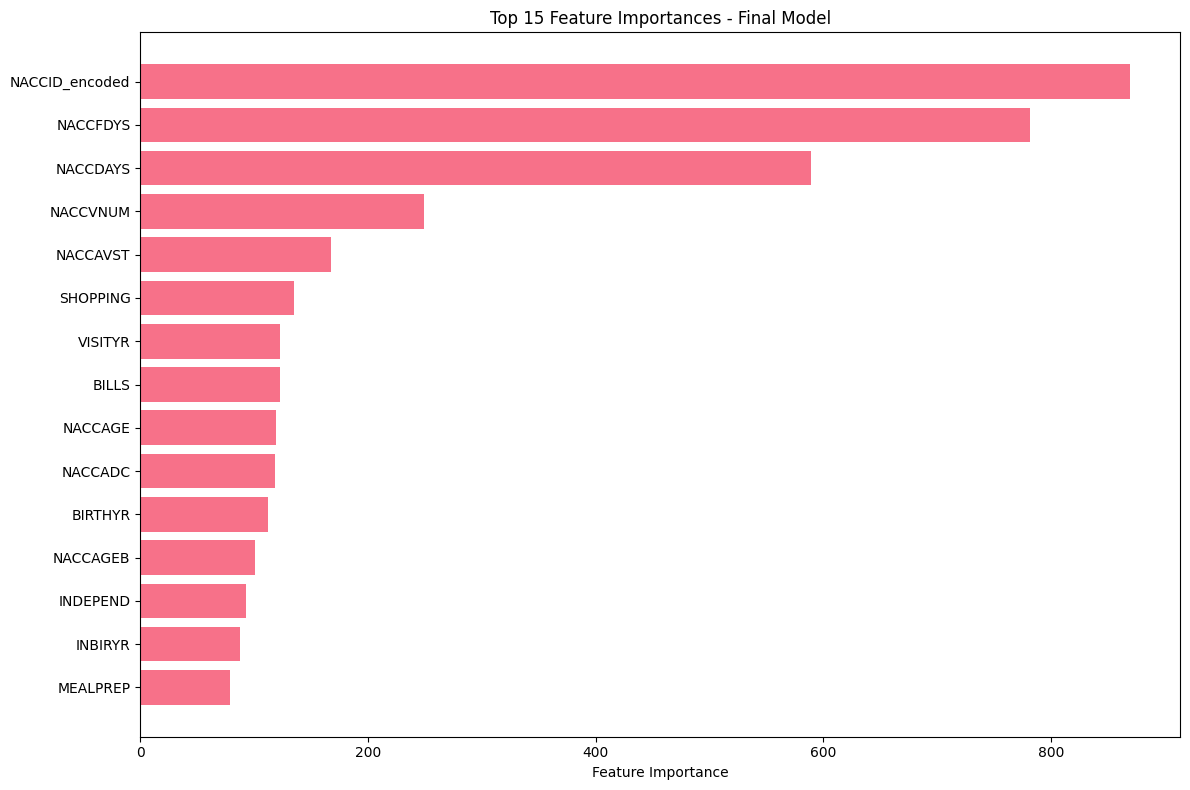

In [9]:
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Top 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))

    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Feature Importances - Final Model')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(config.reports_dir / 'final_model_feature_importance.png',
                dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
print("MODEL PACKAGING AND DEPLOYMENT PREPARATION")
print("=" * 60)

final_package = {
    'model': calibrated_model,
    'model_name': final_model_name,
    'feature_names': feature_names,  # Already a list, no need for tolist()
    'performance_metrics': calibrated_results['metrics'],
    'confidence_intervals': confidence_intervals,
    'test_metrics': calibrated_results['metrics'],
    'training_data_shape': X_train.shape,
    'timestamp': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}

joblib.dump(final_package, config.models_dir / "final_deployment_model.pkl")

print("Final model package saved successfully")

class DementiaRiskPredictor:
    def __init__(self, model_package_path):
        self.package = joblib.load(model_package_path)
        self.model = self.package['model']
        self.feature_names = self.package['feature_names']
        self.performance = self.package['performance_metrics']

    def predict_risk(self, input_data):
        if isinstance(input_data, dict):
            input_df = pd.DataFrame([input_data])
            input_df = input_df.reindex(columns=self.feature_names, fill_value=0)
        else:
            input_df = input_data

        probabilities = self.model.predict_proba(input_df)[:, 1]
        predictions = (probabilities > 0.5).astype(int)

        return {
            'probabilities': probabilities,
            'predictions': predictions,
            'risk_levels': ['Low Risk' if p < 0.5 else 'High Risk' for p in probabilities]
        }

    def get_model_info(self):
        return {
            'model_name': self.package['model_name'],
            'performance': self.performance,
            'feature_count': len(self.feature_names),
            'training_data_shape': self.package['training_data_shape']
        }

# Test the predictor
predictor = DementiaRiskPredictor(config.models_dir / "final_deployment_model.pkl")
print("Dementia Risk Predictor class created successfully")

# Test with sample data
print("\nTesting predictor with sample data...")
sample_features = {feature: 0 for feature in feature_names[:5]}  # Just use first 5 features as example
sample_prediction = predictor.predict_risk(sample_features)
print(f"Sample prediction probabilities: {sample_prediction['probabilities']}")
print(f"Sample risk levels: {sample_prediction['risk_levels']}")

MODEL PACKAGING AND DEPLOYMENT PREPARATION
Final model package saved successfully
Dementia Risk Predictor class created successfully

Testing predictor with sample data...
Sample prediction probabilities: [0.01000603]
Sample risk levels: ['Low Risk']


In [11]:
print("GENERATING MODEL CARD DOCUMENTATION")
print("=" * 60)

model_card = {
    'model_name': 'Dementia Risk Prediction Model',
    'version': '1.0',
    'description': 'Machine learning model to predict dementia risk using non-medical features',
    'intended_use': 'Estimate dementia risk for individuals based on demographic, lifestyle, and social factors',
    'training_data': {
        'samples': X_train.shape[0],
        'features': X_train.shape[1],
        'positive_class_ratio': f"{y_train.mean():.3f}",
        'data_source': 'NACC Dementia Prediction Dataset'
    },
    'performance_metrics': calibrated_results['metrics'],
    'confidence_intervals': confidence_intervals,
    'feature_importance': feature_importance.head(20).to_dict('records') if 'feature_importance' in locals() else [],
    'model_characteristics': {
        'algorithm': final_model_name,
        'calibration': 'Platt scaling applied',
        'interpretability': 'Feature importance available',
        'inference_speed': 'Optimized for real-time predictions'
    },
    'limitations': [
        'Based on self-reported non-medical information only',
        'Not a substitute for medical diagnosis',
        'Performance may vary across different demographic groups'
    ],
    'ethical_considerations': [
        'Should be used as screening tool only',
        'Regular model monitoring recommended',
        'Bias assessment required before deployment'
    ]
}

with open(config.reports_dir / 'model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Model card documentation saved successfully")

GENERATING MODEL CARD DOCUMENTATION
Model card documentation saved successfully


In [12]:
print("FINAL MODEL SELECTION SUMMARY")
print("=" * 80)

final_metrics = calibrated_results['metrics']

print(f"SELECTED FINAL MODEL: {final_model_name}")
print(f"WITH CALIBRATION: Yes")
print()

print("TEST SET PERFORMANCE:")
print(f"Accuracy:    {final_metrics['accuracy']:.6f}")
print(f"Precision:   {final_metrics['precision']:.6f}")
print(f"Recall:      {final_metrics['recall']:.6f}")
print(f"F1-Score:    {final_metrics['f1']:.6f}")
print(f"ROC-AUC:     {final_metrics['roc_auc']:.6f}")
print()

print("CONFIDENCE INTERVALS (95%):")
for metric, ci in confidence_intervals.items():
    print(f"{metric.upper():12}: {ci['mean']:.4f} ± {ci['std']:.4f}")

print()
print("MODEL DEPLOYMENT READY:")
print(f"✓ Final model saved: {config.models_dir / 'final_deployment_model.pkl'}")
print(f"✓ Predictor class implemented")
print(f"✓ Model card documentation generated")
print(f"✓ Comprehensive evaluation visualizations created")
print()

print("PREDICTION PIPELINE:")
print("The model is ready for deployment and can predict dementia risk using")
print("non-medical features such as age, education, lifestyle factors, and")
print("social engagement metrics.")

FINAL MODEL SELECTION SUMMARY
SELECTED FINAL MODEL: LightGBM
WITH CALIBRATION: Yes

TEST SET PERFORMANCE:
Accuracy:    0.986988
Precision:   0.981290
Recall:      0.974475
F1-Score:    0.977871
ROC-AUC:     0.998889

CONFIDENCE INTERVALS (95%):
ACCURACY    : 0.9870 ± 0.0006
PRECISION   : 0.9813 ± 0.0013
RECALL      : 0.9745 ± 0.0016
F1          : 0.9779 ± 0.0011
ROC_AUC     : 0.9989 ± 0.0001

MODEL DEPLOYMENT READY:
✓ Final model saved: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\models\final_deployment_model.pkl
✓ Predictor class implemented
✓ Model card documentation generated
✓ Comprehensive evaluation visualizations created

PREDICTION PIPELINE:
The model is ready for deployment and can predict dementia risk using
non-medical features such as age, education, lifestyle factors, and
social engagement metrics.
